LABORATORIO 1 — Estimación de un GBM con datos de una acción

Activo          : AAPL
Periodo         : 2021-01-01 → 2024-01-01
Obs. diarias    : 752
µ anualizado    : 0.1776  (17.76 %)
σ anualizado    : 0.2777  (27.77 %)


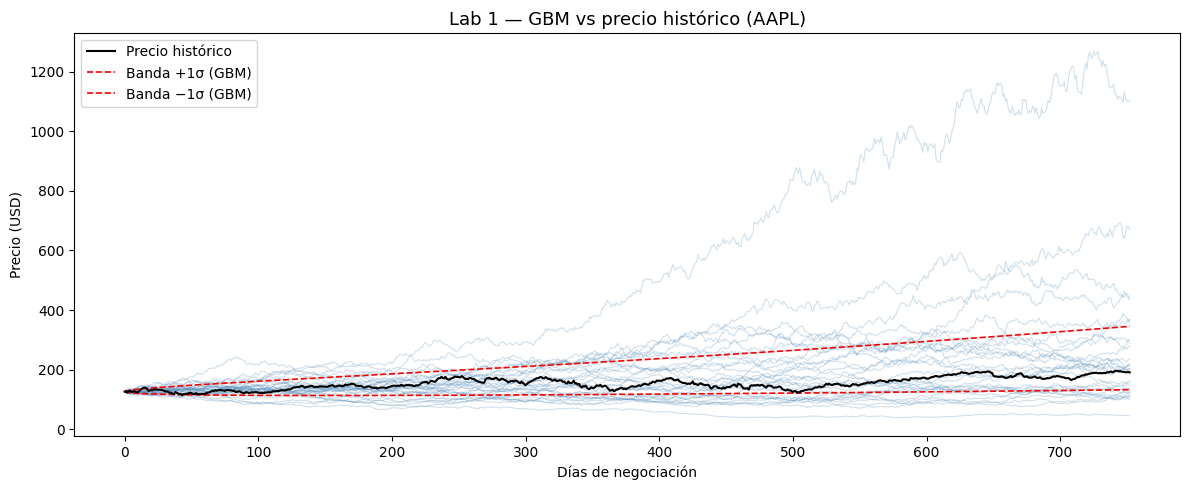

In [ ]:

#  LABORATORIO 1: Estimación de un Movimiento Browniano

import yfinance as yf
import numpy as np
import matplotlib.pyplot as plt

# ── Parámetros ──────────────────────────────────────────────
TICKER   = "AAPL"
START    = "2021-01-01"
END      = "2024-01-01"
N_TRAJ   = 30              # número de trayectorias simuladas
SEED     = 42

# ── 1. Descarga de datos ────────────────────────────────────
data = yf.download(TICKER, start=START, end=END, auto_adjust=True, progress=False)
precios = data["Close"].dropna()

# ── 2. Log-retornos diarios ─────────────────────────────────
log_ret = np.log(precios / precios.shift(1)).dropna()
n_dias  = len(precios)

# ── 3. Estimación de parámetros ─────────────────────────────
m_b  = log_ret.mean().item()                    # media diaria
s_b  = log_ret.std(ddof=1).item()              # desv. est. diaria
mu_anual  = 252 * m_b + 0.5 * 252 * s_b**2
sig_anual = np.sqrt(252) * s_b

print(f"Activo          : {TICKER}")
print(f"Periodo         : {START} → {END}")
print(f"Obs. diarias    : {len(log_ret)}")
print(f"µ anualizado    : {mu_anual:.4f}  ({mu_anual*100:.2f} %)")
print(f"σ anualizado    : {sig_anual:.4f}  ({sig_anual*100:.2f} %)")

# ── 4. Simulación de trayectorias GBM ───────────────────────
rng  = np.random.default_rng(SEED)
dt   = 1 / 252
S0   = precios.iloc[0].item()
T    = (n_dias - 1) * dt
pasos = n_dias - 1

trayectorias = np.zeros((pasos + 1, N_TRAJ))
trayectorias[0] = S0

for j in range(N_TRAJ):
    Z = rng.standard_normal(pasos)
    for i in range(1, pasos + 1):
        trayectorias[i, j] = trayectorias[i-1, j] * np.exp(
            (mu_anual - 0.5 * sig_anual**2) * dt + sig_anual * np.sqrt(dt) * Z[i-1]
        )

# ── 5. Banda ±1σ teórica ────────────────────────────────────
t_vec   = np.linspace(0, T, pasos + 1)
banda_sup = S0 * np.exp(mu_anual * t_vec + sig_anual * np.sqrt(t_vec))
banda_inf = S0 * np.exp(mu_anual * t_vec - sig_anual * np.sqrt(t_vec))

# ── 6. Gráfica ──────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(precios.values, color="black", lw=1.5, label="Precio histórico", zorder=5)
for j in range(N_TRAJ):
    ax.plot(trayectorias[:, j], alpha=0.25, lw=0.8, color="steelblue")
ax.plot(banda_sup, "r--", lw=1.2, label="Banda +1σ (GBM)")
ax.plot(banda_inf, "r--", lw=1.2, label="Banda −1σ (GBM)")
ax.set_title(f"Lab 1 — GBM vs precio histórico ({TICKER})", fontsize=13)
ax.set_xlabel("Días de negociación")
ax.set_ylabel("Precio (USD)")
ax.legend()
plt.tight_layout()
plt.show()

LABORATORIO 2 — Volatilidad realizada y ventanas móviles

Volatilidad realizada anualizada — estadísticas descriptivas
             21d        63d       126d
count  1488.0000  1446.0000  1383.0000
mean      0.1724     0.1808     0.1894
std       0.1138     0.1012     0.0884
min       0.0499     0.0657     0.0848
25%       0.1034     0.1166     0.1278
50%       0.1471     0.1537     0.1641
75%       0.2119     0.2134     0.2233
max       0.9367     0.6044     0.4496


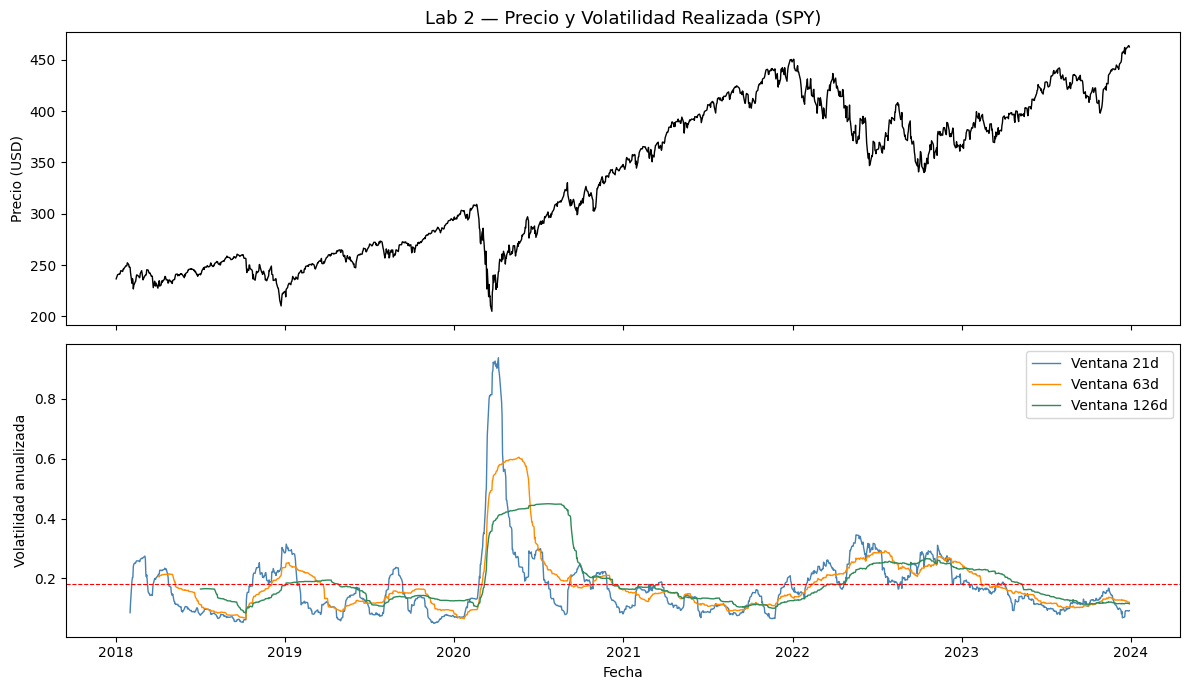


Periodos con vol. 21d > percentil 90 (27.86%):
Date
2018-12-26    0.303378
2018-12-27    0.298139
2018-12-28    0.297261
2018-12-31    0.285348
2019-01-02    0.285854
2019-01-03    0.291485
2019-01-04    0.314585
2019-01-07    0.299577
2019-01-08    0.302426
2019-01-09    0.292876
Name: 21d, dtype: float64


In [ ]:
# ============================================================
#  LABORATORIO 2: Volatilidad realizada y ventanas móviles
# ============================================================

import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ── Parámetros ──────────────────────────────────────────────
TICKER  = "SPY"
START   = "2018-01-01"
END     = "2024-01-01"
VENTANAS = [21, 63, 126]       # días: ~1 mes, 3 meses, 6 meses

# ── 1. Descarga y log-retornos ──────────────────────────────
data    = yf.download(TICKER, start=START, end=END, auto_adjust=True, progress=False)
precios = data["Close"].dropna()
log_ret = np.log(precios / precios.shift(1)).dropna()

# ── 2. Volatilidad realizada en ventana móvil ───────────────
vol_df = pd.DataFrame(index=log_ret.index)
for v in VENTANAS:
    vol_df[f"{v}d"] = log_ret.rolling(v).std(ddof=1) * np.sqrt(252)

# ── 3. Estadísticas descriptivas ────────────────────────────
print("Volatilidad realizada anualizada — estadísticas descriptivas")
print(vol_df.describe().round(4))

# ── 4. Gráfica ──────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

# Panel superior: precio
axes[0].plot(precios, color="black", lw=1)
axes[0].set_title(f"Lab 2 — Precio y Volatilidad Realizada ({TICKER})", fontsize=13)
axes[0].set_ylabel("Precio (USD)")

# Panel inferior: volatilidades
colores = ["steelblue", "darkorange", "seagreen"]
for col, c in zip(vol_df.columns, colores):
    axes[1].plot(vol_df[col], label=f"Ventana {col}", lw=1, color=c)
axes[1].set_ylabel("Volatilidad anualizada")
axes[1].set_xlabel("Fecha")
axes[1].legend()
axes[1].axhline(vol_df.mean().mean(), color="red", lw=0.8, linestyle="--", label="Media global")

plt.tight_layout()
plt.show()

# ── 5. Identificación de periodos turbulentos ───────────────
umbral = vol_df["21d"].quantile(0.90)
turbulentos = vol_df["21d"][vol_df["21d"] > umbral]
print(f"\nPeriodos con vol. 21d > percentil 90 ({umbral:.2%}):")
print(turbulentos.head(10))

LABORATORIO 3 — Valuación Monte Carlo de una opción europea

S0 = 462.58 | K = 480.00 | T = 1.0 año(s)
r  = 0.0450 | σ = 0.1954 (19.54 %)

{'':─<55}
                Monte Carlo   Error std    Black-Scholes
Call             37.8827      0.2708          37.7361
Put              34.0825      0.2050          34.0350


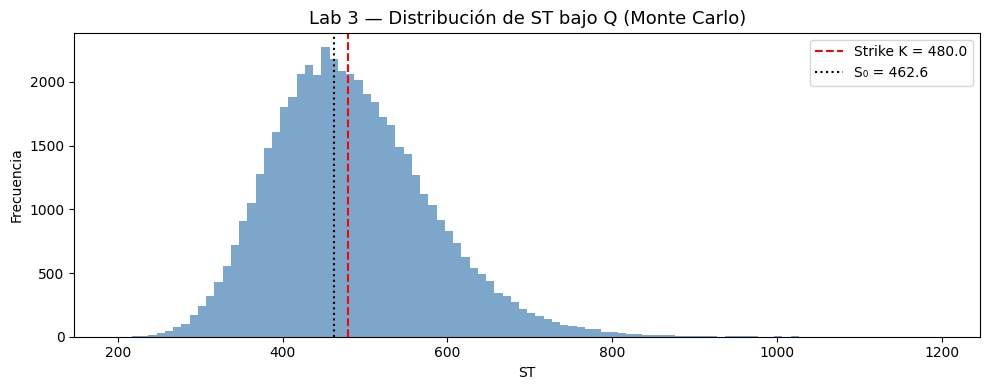

In [ ]:
# ============================================================
#  LABORATORIO 3: Valuación Monte Carlo — Opción Europea
# ============================================================

import yfinance as yf
import numpy as np
from scipy.stats import norm
import matplotlib.pyplot as plt

# ── Parámetros del contrato ─────────────────────────────────
TICKER   = "SPY"
START_CAL= "2022-01-01"
END_CAL  = "2024-01-01"

K        = 480.0     # strike (ajusta al precio actual)
T        = 1.0       # vencimiento en años
r        = 0.045     # tasa libre de riesgo (anual, continua)
N_PATHS  = 50_000    # trayectorias Monte Carlo
SEED     = 0

# ── 1. Calibración de σ con datos históricos ────────────────
data    = yf.download(TICKER, start=START_CAL, end=END_CAL,
                      auto_adjust=True, progress=False)
precios = data["Close"].dropna()
log_ret = np.log(precios / precios.shift(1)).dropna()
sigma   = log_ret.std(ddof=1).item() * np.sqrt(252)
S0      = precios.iloc[-1].item()

print(f"S0 = {S0:.2f} | K = {K:.2f} | T = {T} año(s)")
print(f"r  = {r:.4f} | σ = {sigma:.4f} ({sigma*100:.2f} %)")

# ── 2. Simulación bajo Q ────────────────────────────────────
rng = np.random.default_rng(SEED)
Z   = rng.standard_normal(N_PATHS)
ST  = S0 * np.exp((r - 0.5 * sigma**2) * T + sigma * np.sqrt(T) * Z)

# ── 3. Payoffs y precios ────────────────────────────────────
payoff_call = np.maximum(ST - K, 0)
payoff_put  = np.maximum(K - ST, 0)

C_mc = np.exp(-r * T) * payoff_call.mean()
P_mc = np.exp(-r * T) * payoff_put.mean()
se_C = np.exp(-r * T) * payoff_call.std(ddof=1) / np.sqrt(N_PATHS)
se_P = np.exp(-r * T) * payoff_put.std(ddof=1)  / np.sqrt(N_PATHS)

# ── 4. Fórmula cerrada Black–Scholes ───────────────────────
d1 = (np.log(S0/K) + (r + 0.5*sigma**2)*T) / (sigma*np.sqrt(T))
d2 = d1 - sigma * np.sqrt(T)
C_bs = S0 * norm.cdf(d1) - K * np.exp(-r*T) * norm.cdf(d2)
P_bs = K * np.exp(-r*T) * norm.cdf(-d2) - S0 * norm.cdf(-d1)

# ── 5. Resultados ───────────────────────────────────────────
print("\n{'':─<55}")
print(f"{'':>10}  {'Monte Carlo':>15}  {'Error std':>10}  {'Black-Scholes':>15}")
print(f"Call     {C_mc:>15.4f}  {se_C:>10.4f}  {C_bs:>15.4f}")
print(f"Put      {P_mc:>15.4f}  {se_P:>10.4f}  {P_bs:>15.4f}")

# ── 6. Distribución de ST ───────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(ST, bins=100, color="steelblue", alpha=0.7, edgecolor="none")
ax.axvline(K, color="red", lw=1.5, linestyle="--", label=f"Strike K = {K}")
ax.axvline(S0, color="black", lw=1.5, linestyle=":", label=f"S₀ = {S0:.1f}")
ax.set_title("Lab 3 — Distribución de ST bajo Q (Monte Carlo)", fontsize=13)
ax.set_xlabel("ST")
ax.set_ylabel("Frecuencia")
ax.legend()
plt.tight_layout()
plt.show()

LABORATORIO 4 — Opción americana con Longstaff–Schwartz

S0 = 190.38 | K = 180.00 | σ = 0.2904

Put Europea  (MC)      : 12.9177
Put Americana (LS)     : 13.5018
Prima ejercicio temprano: 0.5841


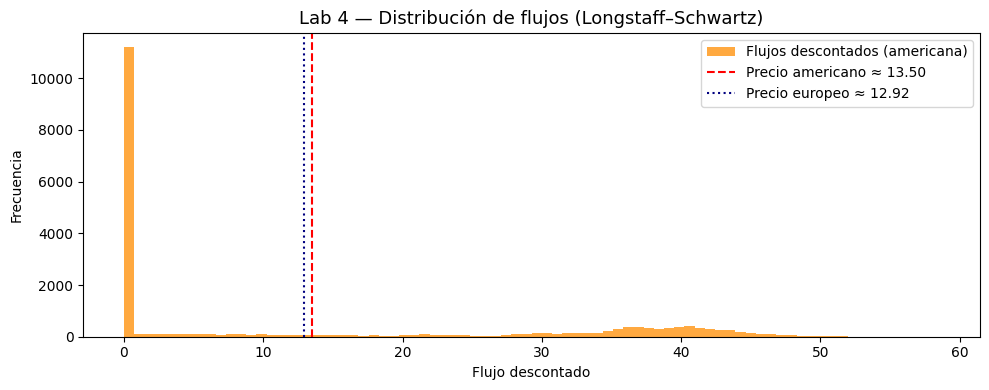

In [ ]:
# ============================================================
#  LABORATORIO 4: Opción Americana — Longstaff–Schwartz
# ============================================================

import yfinance as yf
import numpy as np
from scipy.stats import norm
import matplotlib.pyplot as plt

# ── Parámetros ──────────────────────────────────────────────
TICKER   = "AAPL"
START_CAL= "2022-01-01"
END_CAL  = "2024-01-01"

K        = 180.0
T        = 1.0
r        = 0.045
N_PATHS  = 20_000
N_PASOS  = 50          # pasos de tiempo discretos
SEED     = 7

# ── 1. Calibración ──────────────────────────────────────────
data    = yf.download(TICKER, start=START_CAL, end=END_CAL,
                      auto_adjust=True, progress=False)
precios = data["Close"].dropna()
log_ret = np.log(precios / precios.shift(1)).dropna()
sigma   = log_ret.std(ddof=1).item() * np.sqrt(252)
S0      = precios.iloc[-1].item()
dt      = T / N_PASOS
disc    = np.exp(-r * dt)

print(f"S0 = {S0:.2f} | K = {K:.2f} | σ = {sigma:.4f}")

# ── 2. Simulación de trayectorias bajo Q ────────────────────
rng = np.random.default_rng(SEED)
Z   = rng.standard_normal((N_PASOS, N_PATHS))
S   = np.zeros((N_PASOS + 1, N_PATHS))
S[0] = S0
for t in range(1, N_PASOS + 1):
    S[t] = S[t-1] * np.exp((r - 0.5*sigma**2)*dt + sigma*np.sqrt(dt)*Z[t-1])

# ── 3. Opción europea (referencia) ──────────────────────────
payoff_eur = np.maximum(K - S[-1], 0)
C_eur = np.exp(-r*T) * payoff_eur.mean()

# ── 4. Longstaff–Schwartz para put americana ────────────────
payoff = np.maximum(K - S, 0)          # (N_PASOS+1, N_PATHS)
flujos = payoff[-1].copy()             # flujos al vencimiento

for t in range(N_PASOS - 1, 0, -1):
    itm = payoff[t] > 0               # trayectorias in-the-money
    if itm.sum() == 0:
        flujos *= disc
        continue
    X   = S[t, itm]
    Y   = flujos[itm] * disc
    # Base de regresión: 1, S, S²
    A   = np.column_stack([np.ones_like(X), X, X**2])
    coef, *_ = np.linalg.lstsq(A, Y, rcond=None)
    cont = A @ coef                    # valor de continuación estimado
    ejer = payoff[t, itm]
    ejercer = ejer > cont
    flujos[itm] = np.where(ejercer, ejer, flujos[itm] * disc)
    flujos[~itm] *= disc

C_am = flujos.mean()

# ── 5. Comparación ──────────────────────────────────────────
print(f"\nPut Europea  (MC)      : {C_eur:.4f}")
print(f"Put Americana (LS)     : {C_am:.4f}")
print(f"Prima ejercicio temprano: {C_am - C_eur:.4f}")

# ── 6. Gráfica: distribución de flujos ──────────────────────
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(flujos, bins=80, color="darkorange", alpha=0.75, edgecolor="none",
        label="Flujos descontados (americana)")
ax.axvline(C_am, color="red", lw=1.5, linestyle="--",
           label=f"Precio americano ≈ {C_am:.2f}")
ax.axvline(C_eur, color="navy", lw=1.5, linestyle=":",
           label=f"Precio europeo ≈ {C_eur:.2f}")
ax.set_title("Lab 4 — Distribución de flujos (Longstaff–Schwartz)", fontsize=13)
ax.set_xlabel("Flujo descontado")
ax.set_ylabel("Frecuencia")
ax.legend()
plt.tight_layout()
plt.show()

LABORATORIO 5 — Opción parisina y reloj de barrera

S0 = 462.58 | Barrera H = 425.57 | σ = 0.1954
Call europea (sin barrera) : 37.9284

Sensibilidad respecto al reloj D:
 D (años)  D (días ≈)  Precio parisina  % desactivadas
     0.05          12          34.9768           45.54
     0.10          25          36.3118           37.91
     0.15          37          36.8922           32.90
     0.20          50          37.3044           28.39
     0.25          63          37.5231           24.68


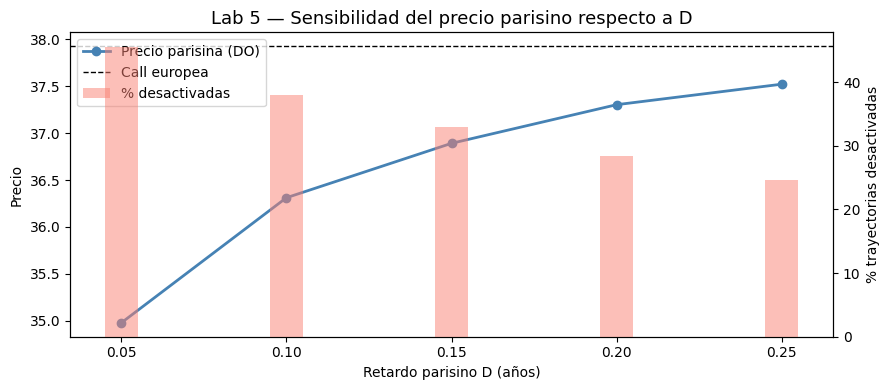

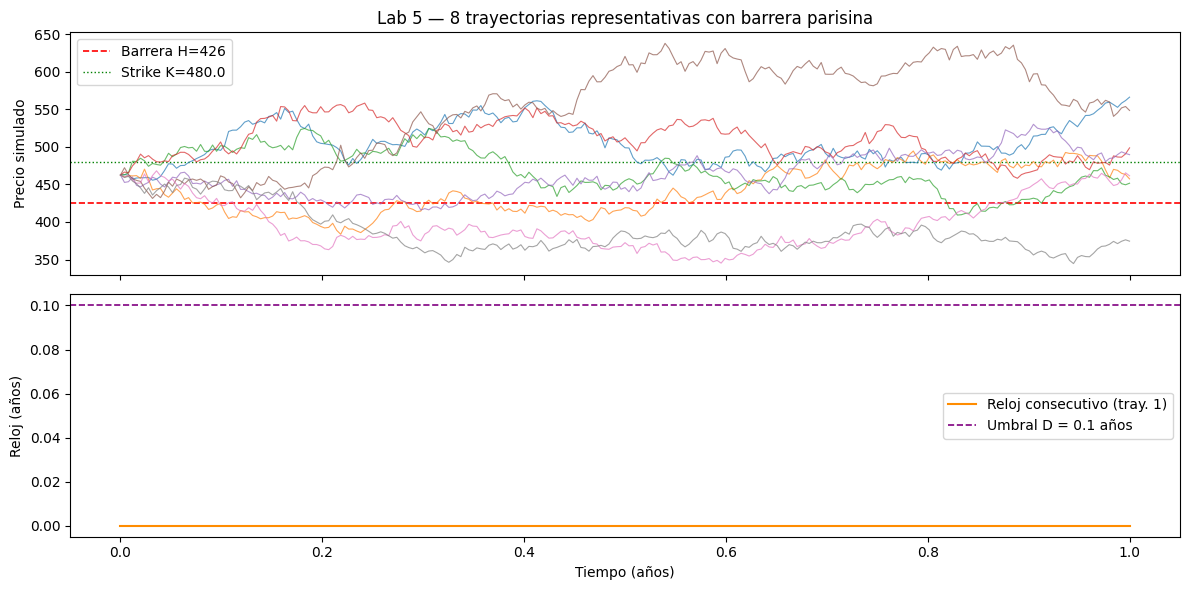

In [ ]:
# ============================================================
#  LABORATORIO 5: Opción Parisina — Reloj de Barrera
# ============================================================

import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ── Parámetros ──────────────────────────────────────────────
TICKER   = "SPY"
START_CAL= "2022-01-01"
END_CAL  = "2024-01-01"

K       = 480.0        # strike
T       = 1.0          # vencimiento (años)
r       = 0.045        # tasa libre de riesgo
N_PATHS = 30_000       # trayectorias
N_PASOS = 252          # pasos diarios
# Barrera por debajo del precio actual (down-and-out parisina)
FRAC_B  = 0.92         # barrera = S0 * FRAC_B
# Valores de D a estudiar (fracción de año)
D_VALS  = [0.05, 0.10, 0.15, 0.20, 0.25]   # ~13, 25, 38, 50, 63 días
SEED    = 99

# ── 1. Calibración ──────────────────────────────────────────
data    = yf.download(TICKER, start=START_CAL, end=END_CAL,
                      auto_adjust=True, progress=False)
precios = data["Close"].dropna()
log_ret = np.log(precios / precios.shift(1)).dropna()
sigma   = log_ret.std(ddof=1).item() * np.sqrt(252)
S0      = precios.iloc[-1].item()
H       = S0 * FRAC_B
dt      = T / N_PASOS

print(f"S0 = {S0:.2f} | Barrera H = {H:.2f} | σ = {sigma:.4f}")

# ── 2. Simulación de trayectorias ───────────────────────────
rng = np.random.default_rng(SEED)
Z   = rng.standard_normal((N_PASOS, N_PATHS))
S   = np.zeros((N_PASOS + 1, N_PATHS))
S[0] = S0
for t in range(1, N_PASOS + 1):
    S[t] = S[t-1] * np.exp((r - 0.5*sigma**2)*dt + sigma*np.sqrt(dt)*Z[t-1])

# ── 3. Función de valuación parisina (reloj consecutivo) ────
def precio_parisina_do(S, K, H, r, dt, D):
    """
    Down-and-out parisina con reloj CONSECUTIVO.
    Se desactiva si S permanece < H durante D años consecutivos.
    Retorna precio MC y fracción de trayectorias desactivadas.
    """
    N_PASOS_, N_PATHS_ = S.shape[0] - 1, S.shape[1]
    D_pasos = int(D / dt)
    reloj   = np.zeros(N_PATHS_, dtype=int)
    vivo    = np.ones(N_PATHS_, dtype=bool)

    for t in range(1, N_PASOS_ + 1):
        bajo_barrera = S[t] < H
        reloj = np.where(bajo_barrera, reloj + 1, 0)
        vivo   = vivo & (reloj < D_pasos)

    payoff = np.where(vivo, np.maximum(S[-1] - K, 0), 0.0)
    precio = np.exp(-r * T) * payoff.mean()
    frac_desact = 1.0 - vivo.mean()
    return precio, frac_desact

# ── 4. Opción europea de referencia (sin barrera) ───────────
C_eur = np.exp(-r*T) * np.maximum(S[-1] - K, 0).mean()
print(f"Call europea (sin barrera) : {C_eur:.4f}")

# ── 5. Sensibilidad en D ────────────────────────────────────
resultados = []
for D in D_VALS:
    precio, frac = precio_parisina_do(S, K, H, r, dt, D)
    resultados.append({"D (años)": D,
                       "D (días ≈)": int(D/dt),
                       "Precio parisina": round(precio, 4),
                       "% desactivadas": round(frac*100, 2)})

df_res = pd.DataFrame(resultados)
print("\nSensibilidad respecto al reloj D:")
print(df_res.to_string(index=False))

# ── 6. Gráfica de sensibilidad ──────────────────────────────
fig, ax1 = plt.subplots(figsize=(9, 4))
ax2 = ax1.twinx()
ax1.plot(D_VALS, df_res["Precio parisina"], "o-", color="steelblue", lw=2,
         label="Precio parisina (DO)")
ax1.axhline(C_eur, color="black", lw=1, linestyle="--", label="Call europea")
ax2.bar(D_VALS, df_res["% desactivadas"], width=0.01,
        color="salmon", alpha=0.5, label="% desactivadas")
ax1.set_xlabel("Retardo parisino D (años)")
ax1.set_ylabel("Precio")
ax2.set_ylabel("% trayectorias desactivadas")
ax1.set_title("Lab 5 — Sensibilidad del precio parisino respecto a D", fontsize=13)
lines1, lab1 = ax1.get_legend_handles_labels()
lines2, lab2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, lab1 + lab2, loc="upper left")
plt.tight_layout()
plt.show()

# ── 7. Visualización de trayectorias con reloj ──────────────
D_VIS  = D_VALS[1]
n_vis  = 8
t_axis = np.linspace(0, T, N_PASOS + 1)

fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
axes[0].axhline(H, color="red", lw=1.2, linestyle="--", label=f"Barrera H={H:.0f}")
axes[0].axhline(K, color="green", lw=1.0, linestyle=":", label=f"Strike K={K}")
for j in range(n_vis):
    axes[0].plot(t_axis, S[:, j], lw=0.8, alpha=0.7)
axes[0].set_ylabel("Precio simulado")
axes[0].set_title(f"Lab 5 — {n_vis} trayectorias representativas con barrera parisina")
axes[0].legend()

# Reloj consecutivo de la primera trayectoria
reloj_vis = np.zeros(N_PASOS + 1)
for t in range(1, N_PASOS + 1):
    reloj_vis[t] = reloj_vis[t-1] + 1 if S[t, 0] < H else 0
axes[1].plot(t_axis, reloj_vis * dt, color="darkorange", lw=1.5,
             label="Reloj consecutivo (tray. 1)")
axes[1].axhline(D_VIS, color="purple", lw=1.2, linestyle="--",
                label=f"Umbral D = {D_VIS} años")
axes[1].set_xlabel("Tiempo (años)")
axes[1].set_ylabel("Reloj (años)")
axes[1].legend()
plt.tight_layout()
plt.show()